 #Todo: 
 - Normalize is making zero diff. File permissions?
 - Low is too strong. Vowels too significant. Need to do hamming and sweeten the high.

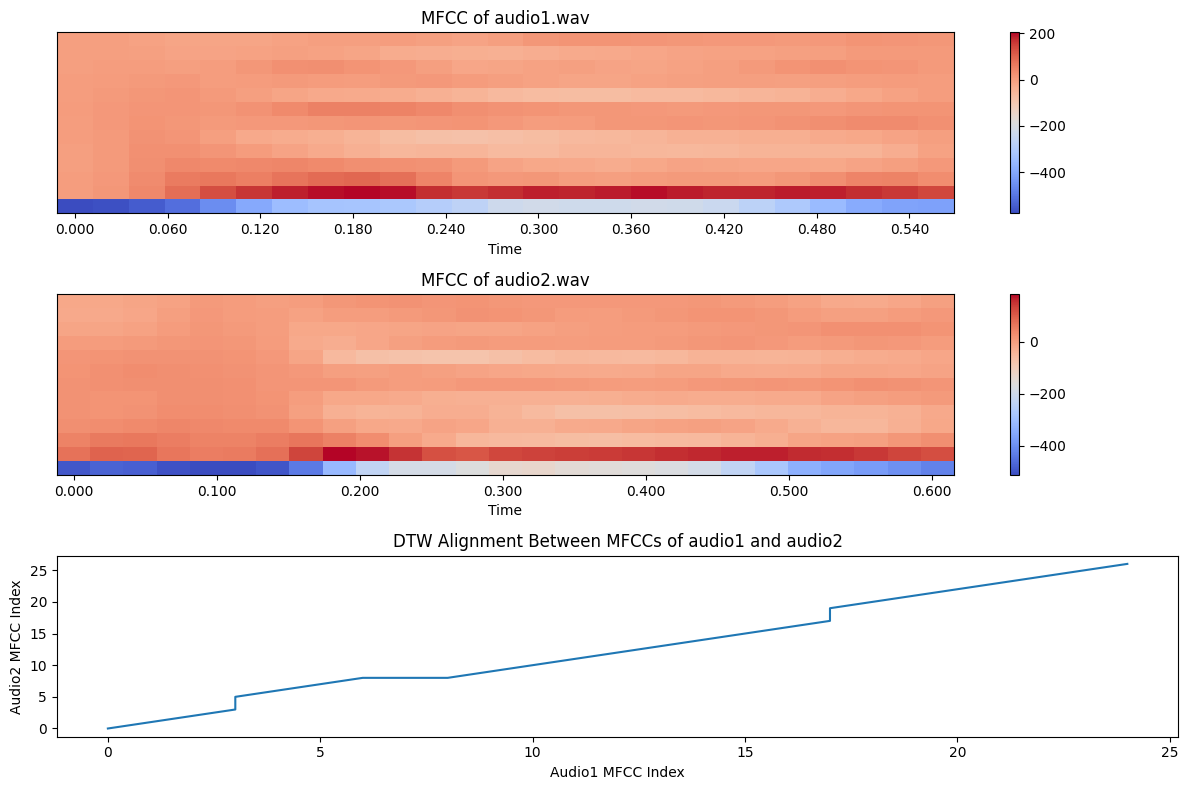

DTW distance between the two audio files: 2843.1953473963454


In [28]:
import librosa
import numpy as np
import matplotlib.pyplot as plt
from fastdtw import fastdtw
from scipy.spatial.distance import euclidean

# Load audio files
#D:\Github\phone-cleaner\phoneme-Samples\Glossika\wav-no-music\[ bʷ ] voiced unaspirated labialized bilabial stop_clean.wav
audio_path1 = 'D:/Github/phone-cleaner/phoneme-Samples/Glossika/tight-snips/iso_[bʷ]_bʷ_voiced unaspirated labialized bilabial stop.wav'
audio_path2 = 'D:/Github/phone-cleaner/phoneme-Samples/Glossika/tight-snips/iso_[b]_b_voiced unaspirated bilabial stop.wav'

y1, sr1 = librosa.load(audio_path1)
y2, sr2 = librosa.load(audio_path2)

# Compute MFCCs
mfcc1 = librosa.feature.mfcc(y=y1, sr=sr1, n_mfcc=13)
mfcc2 = librosa.feature.mfcc(y=y2, sr=sr2, n_mfcc=13)

# Compute DTW
distance, path = fastdtw(mfcc1.T, mfcc2.T, dist=euclidean)

# Plotting the results
plt.figure(figsize=(12, 8))

# Plot MFCCs of audio1
plt.subplot(3, 1, 1)
librosa.display.specshow(mfcc1, sr=sr1, x_axis='time')
plt.colorbar()
plt.title('MFCC of audio1.wav')

# Plot MFCCs of audio2
plt.subplot(3, 1, 2)
librosa.display.specshow(mfcc2, sr=sr2, x_axis='time')
plt.colorbar()
plt.title('MFCC of audio2.wav')

# Plot alignment
plt.subplot(3, 1, 3)
plt.plot([p[0] for p in path], [p[1] for p in path])
plt.title('DTW Alignment Between MFCCs of audio1 and audio2')
plt.xlabel('Audio1 MFCC Index')
plt.ylabel('Audio2 MFCC Index')

plt.tight_layout()
plt.show()

print(f'DTW distance between the two audio files: {distance}')


In [38]:
import librosa
import numpy as np
import matplotlib.pyplot as plt
import os
from fastdtw import fastdtw
from pydub import AudioSegment
import soundfile as sf
from scipy.spatial.distance import euclidean, cosine
verbose = False

process = ""

def plot_mfcc(mfcc):
    # Plot the MFCCs as stacked lines
    plt.figure(figsize=(10, 6))
    n_mfcc = mfcc.shape[0]
    for i in range(n_mfcc):
        plt.plot(mfcc[i] + 50 * i, label=f'MFCC {i+1}')

    plt.xlabel('Time (frames)')
    plt.ylabel('MFCC Coefficients')
    plt.title('Stacked MFCCs')
    plt.legend()
    plt.show()
    
def rms_normalize(audio_path, target_rms=-20):
    audio = AudioSegment.from_file(audio_path)
    
    # Convert the target RMS level to linear scale
    target_rms_linear = 10 ** (target_rms / 20.0)
    
    # Calculate the current RMS level in linear scale
    samples = np.array(audio.get_array_of_samples())
    current_rms_linear = np.sqrt(np.mean(samples**2))
    
    # Calculate the gain factor
    gain_factor = target_rms_linear / current_rms_linear
    
    # Apply gain factor
    normalized_audio = audio.apply_gain(20 * np.log10(gain_factor))
    
    return normalized_audio
    
def rms_normalize_librosa(audio_path, target_level=-20):
    
    
    # Load audio file
    y, sr = librosa.load(audio_path, sr=None)
    
    # Compute the RMS of the audio
    rms = np.sqrt(np.mean(y**2))
    
    # Compute the scaling factor
    scalar = (10**(target_level / 20.0)) / rms
    
    # Apply the scaling factor to normalize the volume
    y_normalized = y * scalar
    
    # Return the normalized audio and sample rate
    return y_normalized, sr

def apply_hamming_window(audio):
    samples = np.array(audio.get_array_of_samples())
    hamming_window = np.hamming(len(samples))
    windowed_samples = samples * hamming_window
    windowed_audio = audio._spawn(windowed_samples.tobytes())
    return windowed_audio

def dtw_adj_sim(audio_path1, audio_path2, measure='euc', normalize=True, plot_diff=False, hamming=False):
    target_level = -20
    if normalize:
        norm_path = 'D:/Github/phone-cleaner/phoneme-Samples/Glossika/normalized_snips/'
        print(os.path.splitext(audio_path1)[0] + ".wav")
        print(norm_path)
        audio1_norm = os.path.join(norm_path, os.path.basename(audio_path1))
        print(audio1_norm)
        if not os.path.exists(audio1_norm):
            normalized_audio, sr = rms_normalize_librosa(audio_path1, target_level)
            if hamming:
                normalized_audio = apply_hamming_window(normalized_audio)
            try:
                sf.write(audio1_norm, normalized_audio, sr, format='WAV', subtype='PCM_16')
                #normalized_audio.export(audio1_norm, format="wav")
                print(f'Normalized audio saved to {audio1_norm}')
            except Exception as e:
                print(f"Error saving normalized audio: {e}")
        else:
            if verbose:
                print(f'Normalized audio already exists at {audio1_norm}')
        audio2_norm = os.path.join(norm_path, os.path.basename(audio_path1))
        if not os.path.exists(audio2_norm):
            normalized_audio, sr = rms_normalize_librosa(audio_path2, target_level)
            if hamming:
                normalized_audio = apply_hamming_window(normalized_audio)
            try:
                sf.write(audio2_norm, normalized_audio, sr, format='WAV', subtype='PCM_16')

                #normalized_audio.export(audio2_norm, format="wav")
                print(f'Normalized audio saved to {audio2_norm}')
            except Exception as e:
                print(f"Error saving normalized audio: {e}")
        else:
            if verbose:
                print(f'Normalized audio already exists at {audio2_norm}')
                
        y1, sr1 = librosa.load(audio1_norm)
        y2, sr2 = librosa.load(audio2_norm)
    else:
        y1, sr1 = librosa.load(audio_path1)
        y2, sr2 = librosa.load(audio_path2)

    # Compute MFCCs
    mfcc1 = librosa.feature.mfcc(y=y1, sr=sr1, n_mfcc=13)

    mfcc2 = librosa.feature.mfcc(y=y2, sr=sr2, n_mfcc=13)
    if verbose:
        plot_mfcc(mfcc1)
        plot_mfcc(mfcc2)
        print("MFCCs computed")
        print(f"MFCC1 shape: {mfcc1.shape}, MFCC2 shape: {mfcc2.shape}")
    
    # Transpose MFCCs to shape (time, n_mfcc)
    mfcc1 = mfcc1.T
    mfcc2 = mfcc2.T

    # Compute DTW
    distance, path = fastdtw(mfcc1, mfcc2, dist=euclidean)
    
    # Create aligned MFCC arrays
    try:
        aligned_mfcc1 = np.zeros((len(path), mfcc1.shape[1]))
        aligned_mfcc2 = np.zeros((len(path), mfcc2.shape[1]))
    except Exception as e:
        print("Error aligning audio file:", e)

    # Apply DTW path to align MFCCs
    for i, (ix1, ix2) in enumerate(path):
        aligned_mfcc1[i] = mfcc1[ix1]
        aligned_mfcc2[i] = mfcc2[ix2]
     
    # Transpose back to (n_mfcc, time)
    aligned_mfcc1 = aligned_mfcc1.T
    aligned_mfcc2 = aligned_mfcc2.T
    
    if verbose:
        print(f"Aligned MFCC1 shape: {aligned_mfcc1.shape}, Aligned MFCC2 shape: {aligned_mfcc2.shape}")
        print("MFCCs aligned")
    
    min_length = min(len(aligned_mfcc1), len(aligned_mfcc2))
    aligned_mfcc1 = aligned_mfcc1[:min_length]
    aligned_mfcc2 = aligned_mfcc2[:min_length]
    if verbose:
        print("Aligned 1")
        plot_mfcc(aligned_mfcc1)
        print("Aligned 2")
        plot_mfcc(aligned_mfcc2)
        print("mfccs done")
    
    if plot_diff:
        mfcc_diff = aligned_mfcc2 - aligned_mfcc1
        print(mfcc_diff)
        plt.subplot(3, 1, 3)
        librosa.display.specshow(mfcc_diff, sr=sr1, x_axis='time')
        plt.colorbar()
        plt.title('Difference between MFCCs')
        
    
    # Calculate Euclidean distance
    if measure == "euc":
        euclidean_similarity = np.mean([euclidean(aligned_mfcc1[i], aligned_mfcc2[i]) for i in range(len(aligned_mfcc1))])
        return euclidean_similarity
    if measure == "cos":
        cosine_similarity = np.mean([1 - cosine(aligned_mfcc1[i], aligned_mfcc2[i]) for i in range(len(aligned_mfcc1))])
        return cosine_similarity
    
    

def dtw(audio_path1, audio_path2):
    
    
    y1, sr1 = librosa.load(audio_path1)
    y2, sr2 = librosa.load(audio_path2)

    # Compute MFCCs
    mfcc1 = librosa.feature.mfcc(y=y1, sr=sr1, n_mfcc=13)
    mfcc2 = librosa.feature.mfcc(y=y2, sr=sr2, n_mfcc=13)

    # Compute DTW
    distance, path = fastdtw(mfcc1.T, mfcc2.T, dist=euclidean)

    return distance

def raw_distance(audio_path1, audio_path2):
    measure = "euc"
    
    y1, sr1 = librosa.load(audio_path1)
    y2, sr2 = librosa.load(audio_path2)

    # Compute MFCCs
    mfcc1 = librosa.feature.mfcc(y=y1, sr=sr1, n_mfcc=13)
    mfcc2 = librosa.feature.mfcc(y=y2, sr=sr2, n_mfcc=13)

    if measure == "euc":
        euclidean_similarity = np.mean([euclidean(mfcc1[i], mfcc2[i]) for i in range(len(mfcc1))])
        return euclidean_similarity
    if measure == "cos":
        cosine_similarity = np.mean([1 - cosine(mfcc1[i], mfcc2[i]) for i in range(len(mfcc1))])
        return cosine_similarity


input_folder = "D:/Github/phone-cleaner/phoneme-Samples/Glossika/tight-snips/"
je_folder = "D:/Github/phone-cleaner/phoneme-Samples/IPA/JE"
jw_folder = "D:/Github/phone-cleaner/phoneme-Samples/IPA/JW"
jh_folder = "D:/Github/phone-cleaner/phoneme-Samples/IPA/JH"
pl_folder = "D:/Github/Github/phone-cleaner/phoneme-Samples/IPA/PL"

paths = [
    "D:/Github/phone-cleaner/phoneme-Samples/Glossika/tight-snips/"
#    "C:/Github/phone-cleaner/phoneme-Samples/IPA/JE", 
#    "C:/Github/phone-cleaner/phoneme-Samples/IPA/JW",
#    "C:/Github/phone-cleaner/phoneme-Samples/IPA/JH",
#    "C:/Github/phone-cleaner/phoneme-Samples/IPA/PL"
]

search = ''
loc = "iso"
process+= search + "_"
process+= loc + "_"
process += "dtwaligned_" 

table = []
for folder in paths:
    print(folder)
    for filename in os.listdir(folder):
        if filename.endswith(".wav") and not filename.startswith("temp"):
            if ("nasal" in filename): ####### Temporary filter for nasal sounds
                audio_path = os.path.join(input_folder, filename)
                IDs = os.path.splitext(filename)[0].split('_')
                IDs.append(filename)

                if search in IDs[3]:
                    if IDs[0].startswith(loc):
                        table.append(IDs)
        
print(table)
        


D:/Github/phone-cleaner/phoneme-Samples/Glossika/tight-snips/
[['iso', '[m]', 'm', 'voiced bilabial nasal stop', 'iso_[m]_m_voiced bilabial nasal stop.wav'], ['iso', '[mʲ]', 'mʲ', 'voiced palatalized bilabial nasal stop', 'iso_[mʲ]_mʲ_voiced palatalized bilabial nasal stop.wav'], ['iso', '[mʷ]', 'mʷ', 'unvoiced labialized bilabial nasal stop', 'iso_[mʷ]_mʷ_unvoiced labialized bilabial nasal stop.wav'], ['iso', '[mʷʲ]', 'mʷʲ', 'voiced unaspirated labialized palatalized bilabial nasal stop', 'iso_[mʷʲ]_mʷʲ_voiced unaspirated labialized palatalized bilabial nasal stop.wav'], ['iso', '[mˁ]', 'mˁ', 'voiced pharyngealized bilabial nasal stop', 'iso_[mˁ]_mˁ_voiced pharyngealized bilabial nasal stop.wav'], ['iso', '[mˠ]', 'mˠ', 'voiced unaspirated velarized bilabial nasal stop', 'iso_[mˠ]_mˠ_voiced unaspirated velarized bilabial nasal stop.wav'], ['iso', '[m̥]', 'm̥', 'unvoiced bilabial nasal stop', 'iso_[m̥]_m̥_unvoiced bilabial nasal stop.wav'], ['iso', '[m̥ʷ]', 'm̥ʷ', 'unvoiced labialized b

In [ ]:

filenames = [sub_array[4] for sub_array in table]
phones = [sub_array[2] for sub_array in table]
names = [sub_array[3] for sub_array in table]
title = [f'{sub_array[2]} - {sub_array[3]}' for sub_array in table]
print(len(filenames))
print(len(table))


print(f'Calculating {len(filenames)} DTWs, this may take a while.')

# Compute Distances and store them in a matrix
n = len(filenames)
dtw_matrix = np.zeros((n, n), dtype=float)
measure = "euc"
process += measure + "_"
normalize = False
if normalize:
    process += "norm_"

print(process)    
    
for i in range(n):
    print(f'{i}')
    #if (i>0) and ((i % 100) == 0):
    #    print(str(i) + " phones processed of "+ str(n) +".") 
    for j in range(n):
        audio_path1 = os.path.join(input_folder, filenames[i])
        print(audio_path1)
        audio_path2 = os.path.join(input_folder, filenames[j])
        print(audio_path2)
        
    
        #try:
            # True for Normalize
        dtw_matrix[i, j] = dtw_adj_sim(audio_path1, audio_path2, measure, normalize)
        #except Exception as e:
        #    print("Calculating DTW:", e)
        #    print(audio_path1)
        #    print(audio_path2)
        #    continue
        
print('Finished calculating DTWs.')
print(dtw_matrix)

38
38
Calculating 38 DTWs, this may take a while.
_iso_dtwaligned_euc_
0
D:/Github/phone-cleaner/phoneme-Samples/Glossika/tight-snips/iso_[m]_m_voiced bilabial nasal stop.wav
D:/Github/phone-cleaner/phoneme-Samples/Glossika/tight-snips/iso_[m]_m_voiced bilabial nasal stop.wav
D:/Github/phone-cleaner/phoneme-Samples/Glossika/tight-snips/iso_[m]_m_voiced bilabial nasal stop.wav
D:/Github/phone-cleaner/phoneme-Samples/Glossika/tight-snips/iso_[m]_m_voiced bilabial nasal stop.wav
D:/Github/phone-cleaner/phoneme-Samples/Glossika/tight-snips/iso_[m]_m_voiced bilabial nasal stop.wav
D:/Github/phone-cleaner/phoneme-Samples/Glossika/tight-snips/iso_[m]_m_voiced bilabial nasal stop.wav
D:/Github/phone-cleaner/phoneme-Samples/Glossika/tight-snips/iso_[m]_m_voiced bilabial nasal stop.wav
D:/Github/phone-cleaner/phoneme-Samples/Glossika/tight-snips/iso_[m]_m_voiced bilabial nasal stop.wav
D:/Github/phone-cleaner/phoneme-Samples/Glossika/tight-snips/iso_[m]_m_voiced bilabial nasal stop.wav
D:/Github

Making a matrix dataframe...
Done
Clustering phones by phonetic similarity....
Generating dendrogram of phonetic similarity....
Rendering the matrix image...
Dendrogram Saved
Displaying Dendrogram...


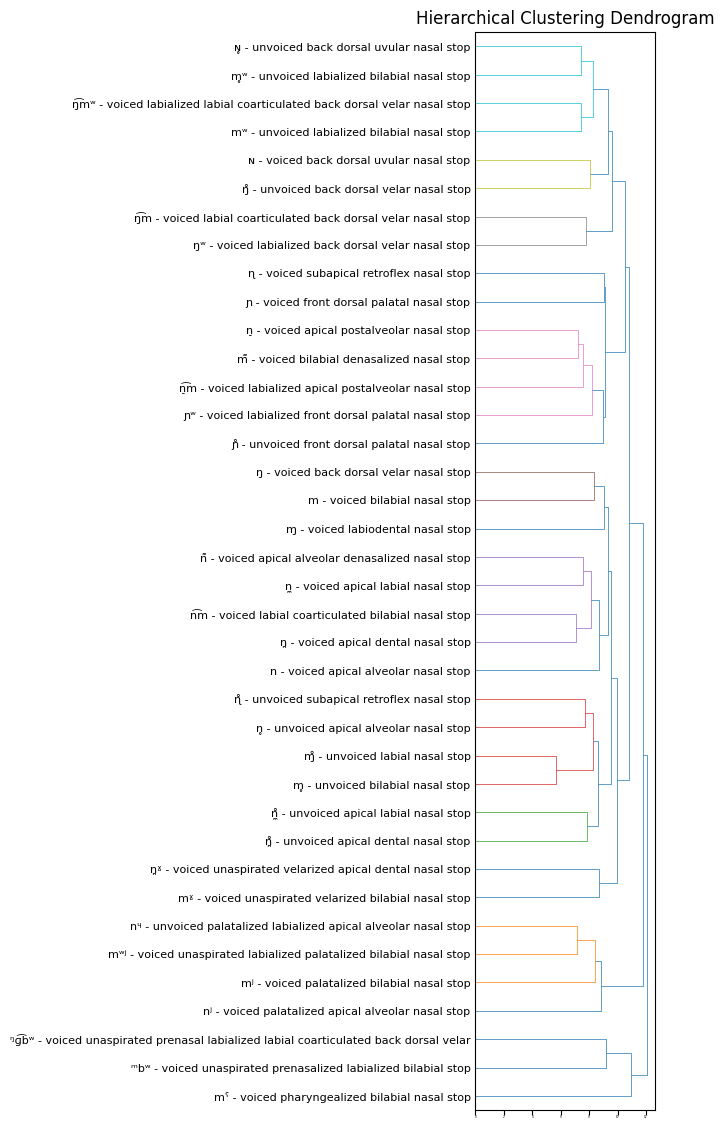

In [46]:
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform
import matplotlib.pyplot as plt 
import pandas as pd

print('Making a matrix dataframe...')
# Create a DataFrame for better visualization
distance_df = pd.DataFrame(dtw_matrix, columns=phones, index=phones)
print("Done")

print('Clustering phones by phonetic similarity....')

# Custom transformation (a combination of linear and logarithmic scaling)
custom_transformed_distances = dtw_matrix ** 0.45

# Perform hierarchical clustering
linked = linkage(squareform(custom_transformed_distances), method='complete', metric='euclidean' ) # method='complete' metric='euclidean'
height = 14
print('Generating dendrogram of phonetic similarity....')
# Create a dendrogram to visualize the clustering
plt.figure(figsize=(2, height))
plt.rcParams['lines.linewidth'] = 0.5
plt.rcParams['xtick.labelsize'] = 2  # Adjust the font size for x-axis tick labels
plt.rcParams['ytick.labelsize'] = 1
dendrogram_object = dendrogram(linked, orientation='right', labels=title)
dendrogram_object['ivl'] = title
plt.title('Hierarchical Clustering Dendrogram')
plt.tick_params(axis='both', which='both', pad=0)
plt.subplots_adjust(left=0)
    


exportFiles = True
image_folder = "D:/Github/phone-cleaner/phoneme-Samples/Glossika/images/"
if exportFiles:
    print('Rendering the matrix image...')
    fn = image_folder + f'\{process}_SortedDendrogram.png'
    plt.savefig(fn, dpi=1000, bbox_inches='tight')
    print('Dendrogram Saved')
    
print('Displaying Dendrogram...')
plt.show()


In [47]:
print('Reordering the Matrix to match the dendrogram...')
# Reorder the distance matrix based on the clustering
order = dendrogram(linked, no_plot=True)['leaves']
distance_df = distance_df.iloc[order, order]
print('Done.')

Reordering the Matrix to match the dendrogram...
Done.


Creating the new matrix...
Rendering the matrix image...
SortedHeatmap saved in {folder} folder.
Displaying the Matrix image...


<Figure size 4000x4000 with 0 Axes>

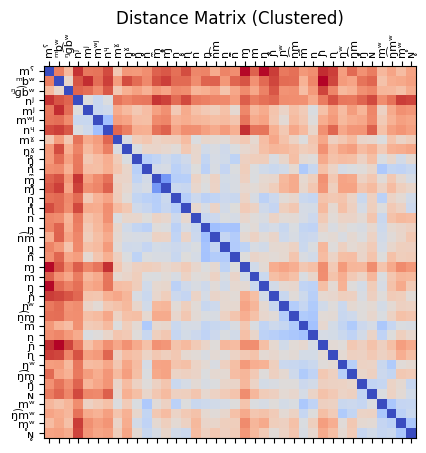

In [48]:
print('Creating the new matrix...')

# Create a heatmap for the reordered distance matrix
size = int(n/30) + 1
plt.rcParams['xtick.labelsize'] = 8  # Adjust the font size for x-axis tick labels
plt.rcParams['ytick.labelsize'] = 8  # 2 to 8
plt.figure(figsize=(size, size), dpi=2000)
#figure, ax = plt.subplots(figsize=(40, 40)) 

cax = plt.matshow(distance_df, cmap='coolwarm', aspect='auto')
# plt.colorbar(cax)

# Customize the plot (optional)
plt.xticks(np.arange(n), distance_df.columns, rotation=90)
plt.yticks(np.arange(n), distance_df.index)



plt.title('Distance Matrix (Clustered)')

exportFiles = True
image_folder = "D:/Github/phone-cleaner/phoneme-Samples/Glossika/images/"
if exportFiles:
    print('Rendering the matrix image...')
    fn = image_folder + f'\{process}_SortedHeatmap.png'
    plt.savefig(fn, dpi=2000, bbox_inches='tight')
    print('SortedHeatmap saved in {folder} folder.')
# Display the plot
print('Displaying the Matrix image...')
plt.show()

In [93]:
diffloc = 'iso'
diffTable = []
for filename in os.listdir(input_folder):
    if filename.endswith(".wav") and not filename.startswith("temp"):
        audio_path = os.path.join(input_folder, filename)
        diffIDs = os.path.splitext(filename)[0].split('_')
        diffIDs.append(filename)
        if diffIDs[0].startswith(diffloc):
            diffTable.append(diffIDs)
        
print(diffTable)

diffPhones = [sub_array[2] for sub_array in diffTable]
diffFilenames = [sub_array[4] for sub_array in diffTable]
        

[['iso', '[b]', 'b', 'voiced unaspirated bilabial stop', 'iso_[b]_b_voiced unaspirated bilabial stop.wav'], ['iso', '[bʱ]', 'bʱ', 'voiced aspirated bilabial stop', 'iso_[bʱ]_bʱ_voiced aspirated bilabial stop.wav'], ['iso', '[bʲ]', 'bʲ', 'voiced unaspirated palatalized bilabial stop', 'iso_[bʲ]_bʲ_voiced unaspirated palatalized bilabial stop.wav'], ['iso', '[bʷ]', 'bʷ', 'voiced unaspirated labialized bilabial stop', 'iso_[bʷ]_bʷ_voiced unaspirated labialized bilabial stop.wav'], ['iso', '[bˁ]', 'bˁ', 'voiced unaspirated pharyngealized bilabial stop', 'iso_[bˁ]_bˁ_voiced unaspirated pharyngealized bilabial stop.wav'], ['iso', '[bˠ]', 'bˠ', 'voiced unaspirated velarized bilabial stop', 'iso_[bˠ]_bˠ_voiced unaspirated velarized bilabial stop.wav'], ['iso', '[b̪]', 'b̪', 'voiced unaspirated labiodental stop', 'iso_[b̪]_b̪_voiced unaspirated labiodental stop.wav'], ['iso', '[b̪ʱ]', 'b̪ʱ', 'voiced aspirated labiodental stop', 'iso_[b̪ʱ]_b̪ʱ_voiced aspirated labiodental stop.wav'], ['iso', '[b

In [130]:
import panphon
from itertools import combinations

print(diffPhones)
print(f'Phones: {len(diffPhones)}')

# Initialize panphon feature table
ft = panphon.FeatureTable()

# Function to calculate the difference in binary features
def diff_by_one_feature(phone1, phone2):
    features1 = ft.word_to_vector_list(phone1)
    features2 = ft.word_to_vector_list(phone2)
    
    # Check if feature vectors are not empty
    if not features1 or not features2:
        if verbose:
            print(f"Error: No feature vector for {phone1} or {phone2}")
        return False, None
    
    features1 = features1[0]
    features2 = features2[0]
    
    differences = [(i, f1, f2) for i, (f1, f2) in enumerate(zip(features1, features2)) if f1 != f2]
    if verbose:
        if 0 <= len(differences) <= 2:
            print(f'{phone1}, {phone2}, {differences}')
    if len(differences) == 1:
        diff_index, f1, f2 = differences[0]
        return True, ft.names[diff_index]
    else:
        return False, None

all_pairs = list(combinations(diffPhones, 2))
print(f'Possibilities: {len(all_pairs)}.')

# Find pairs that differ by only one binary feature
similar_pairs = set()
for p1, p2 in all_pairs:
    if verbose:
        print(f"Comparing {p1} and {p2}")
    are_similar, differing_feature = diff_by_one_feature(p1, p2)
    if are_similar:
        similar_pairs.add((p1, p2, differing_feature))
verbose = False        
# Print the pairs
if verbose:
    for pair in similar_pairs:
        print(pair)


# Convert set of tuples to list of lists
pairs = np.array([list(item) for item in similar_pairs])

print(f'Pairs with single-feature match: {len(data)}')


['b', 'bʱ', 'bʲ', 'bʷ', 'bˁ', 'bˠ', 'b̪', 'b̪ʱ', 'b̪̎', 'b͈', 'cʰ', 'cʼ', 'c͈', 'c⁼', 'd', 'dʱ', 'dʲ', 'dʷ', 'dˤ', 'd̠', 'd̪', 'd̪ʱ', 'd̪ʷ', 'd̪ˠ', 'd̼', 'd̼ʱ', 'd̼̎', 'd͈', 'd͡b', 'f', 'fʷ', 'fˁ', 'h', 'hʷ', 'hˁ', 'kʰ', 'kʰʲ', 'kʰʷ', 'kʲ', 'kʲʼ', 'kʷ', 'kʼ', 'kʼʷ', 'k͈', 'k͡p', 'k͡pʷ', 'k⁼', 'm', 'mʲ', 'mʷ', 'mʷʲ', 'mˁ', 'mˠ', 'm̥', 'm̥ʷ', 'm͊', 'n', 'nʲ', 'n̠', 'n̠͡m', 'n̥', 'n̪', 'n̪ˠ', 'n̪̊', 'n̼', 'n̼̊', 'n͊', 'n͡m', 'nᶣ', 'pʰ', 'pʰʲ', 'pʰʷ', 'pʲ', 'pʷ', 'pʷʲ', 'pʼ', 'pˁ', 'pˠ', 'p̎ b̥̎', 'p̪ʰ', 'p̪⁼', 'p⁼', 'qʰ', 'qʷ', 'qʷ', 'qʷʼ', 'qʼ', 'qˁ', 'qˤʷʼ', 'qˤʼ', 'q̎', 'q⁼', 'r', 'r̠', 'r̠̊', 'r̥', 'r̪', 'r̪̊', 'r̼', 'r̼̊', 'sˁ', 's̪ʲ', 's̱', 's̺ s', 's̻', 'txʷ', 'tʰ', 'tʰʲ', 'tʰʷ', 'tʲ', 'tʼ', 'tˤ', 't̠', 't̪ʰ', 't̪ʷ', 't̪ʼ', 't̪ˠ', 't̪⁼', 't̼ʰ', 't̼̎', 't̼⁼', 't͈', 't͡p', 't⁼', 'v', 'vʷ', 'vˁ', 'wˁ', 'x', 'xʲ', 'xʷ', 'zˁ', 'z̪', 'z̪ʲ', 'z̺̪', 'z̻', 'ç', 'çʷ', 'ðʷ', 'ðˁ', 'ð̼', 'ħ', 'ħʷ', 'ŋ', 'ŋʷ', 'ŋ̊', 'ŋ͡m', 'ŋ͡mʷ', 'ɓ', 'ɓ̥ ƥ', 'ɖ', 'ɖʱ', 'ɖ̎', 'ɗ', 'ɗ̥ ƭ', 'ɠ', 'ɠ̊ ƙ', 'ɣ', 'ɣʲ

In [131]:


from collections import defaultdict

# Sample data: list of arrays, each array has three elements
data = pairs

def find_filemname_by_pattern(diffTable, pattern="pattern"):
    for item in diffTable:
        if (len(item) > 3) and (item[2] == pattern):
            return item[4]
    return None

# Grouping by the third value
grouped_data = defaultdict(list)
for item in data:
    grouped_data[item[2]].append(item)

input_folder = "C:/Github/phone-cleaner/phoneme-Samples/Glossika/tight-snips/"
# Calculate average Levenshtein distance within each group
average_distances = {}
length_of_set = {}
for group, items in grouped_data.items():
    distances = []
    for item in items:
        filename1 = os.path.join(input_folder, find_filemname_by_pattern(diffTable, item[0]))
        filename2 = os.path.join(input_folder,find_filemname_by_pattern(diffTable, item[1]))
        if verbose:
            print(filename1)
            print(filename2)
            
        distances.append(dtw_adj_sim(filename1, filename2, measure, normalize))
    average_distances[group] = sum(distances) / len(distances)
    length_of_set[group] = len(distances)

    
# Print the results
for group, avg_distance in average_distances.items():
    print(f"{group}: {avg_distance}")
    
for group, lengthy in length_of_set.items():
    print(f"{group}: {lengthy}")


lat: 105.48642929225592
cont: 133.86989341717043
lab: 125.79773924537689
voi: 114.24596918480232
back: 105.42916258939151
round: 116.53413091884467
distr: 102.50807451601187
hi: 121.49024096676071
cg: 112.69365438432008
ant: 98.27142568328517
sg: 91.7128704483088
lo: 119.21663676384489
son: 91.36084779206921
strid: 92.81089242397638
lat: 44
cont: 95
lab: 49
voi: 272
back: 48
round: 38
distr: 73
hi: 84
cg: 88
ant: 68
sg: 38
lo: 15
son: 3
strid: 7


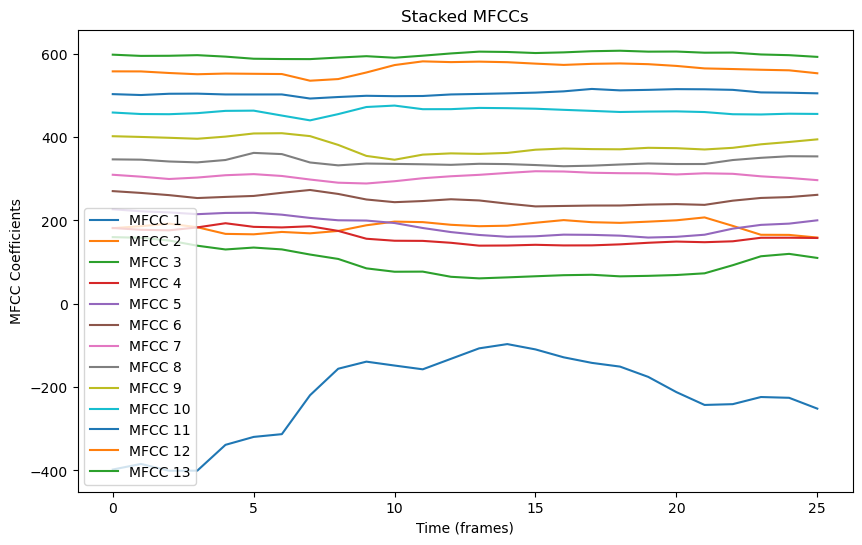

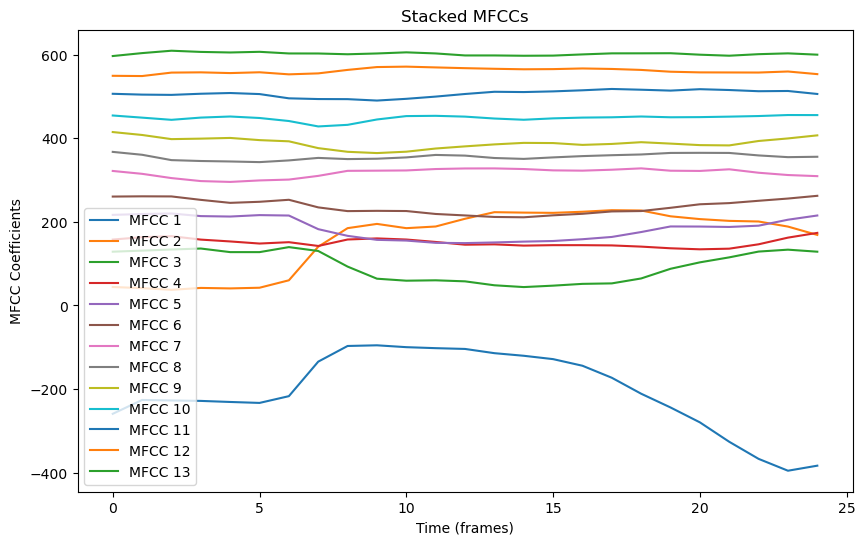

MFCC1 shape: (13, 26), MFCC2 shape: (13, 25)
Aligned MFCC1 shape: (13, 27), Aligned MFCC2 shape: (13, 27)
MFCCs aligned
Aligned 1


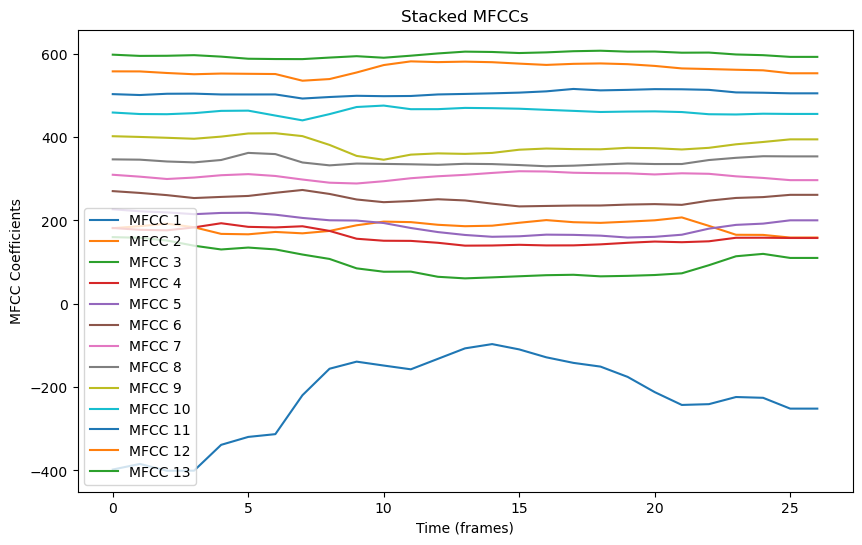

Aligned 2


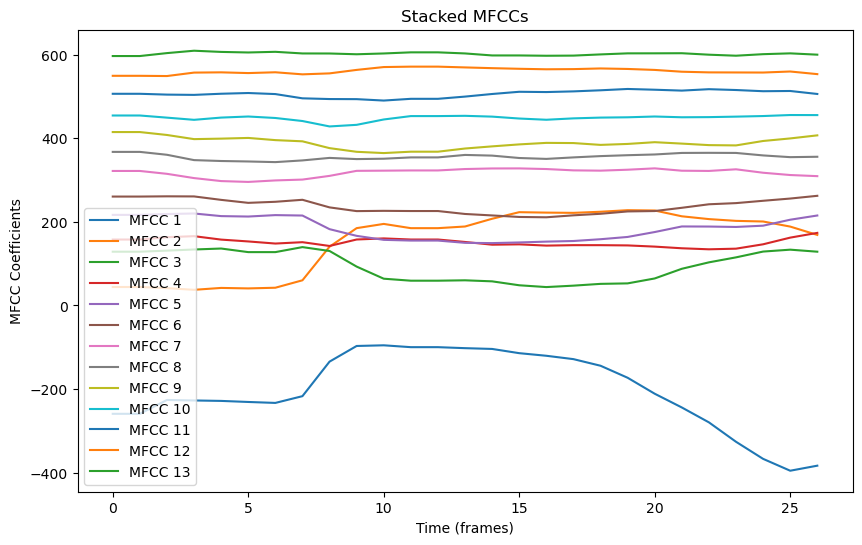

mfccs done
[[ 1.38610565e+02  1.25175201e+02  1.74570740e+02  1.73222534e+02
   1.10201843e+02  8.86450348e+01  7.97327728e+01  2.50469971e+00
   2.15205841e+01  4.19846802e+01  5.29400711e+01  5.75306168e+01
   3.23668594e+01  4.83971405e+00 -7.24015808e+00 -4.60878754e+00
   8.14420319e+00  1.34579468e+01  6.58251953e+00  2.48622131e+00
   8.44757080e-01 -1.25444031e+00 -3.87757721e+01 -1.02384415e+02
  -1.41394958e+02 -1.43803711e+02 -1.31725098e+02]
 [-1.37289842e+02 -1.42035844e+02 -1.50771392e+02 -1.46249313e+02
  -1.25759802e+02 -1.25900763e+02 -1.29956780e+02 -1.08842768e+02
  -3.41581955e+01 -3.35058594e+00 -2.01466370e+00 -1.09589844e+01
  -4.55535889e+00  2.81433105e+00  2.00892944e+01  2.87943726e+01
   2.14054108e+01  2.58430786e+01  3.00950470e+01  3.09150848e+01
   2.69485474e+01  6.16314697e+00  1.97318573e+01  3.68738251e+01
   3.56564636e+01  2.99106216e+01  9.96338654e+00]
 [-3.12629375e+01 -2.96819439e+01 -2.05665398e+01 -5.40959930e+00
   5.93421936e+00 -7.24259949

124.95726322600892

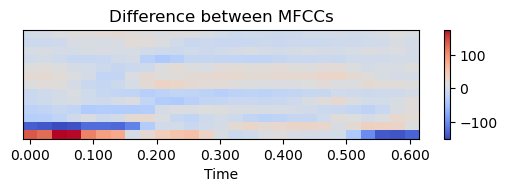

In [24]:
# def dtw_adj_sim(audio_path1, audio_path2, measure='euc', normalize=True, plot_diff=False):
simple = 'C:/Github/phone-cleaner/phoneme-Samples/Glossika/tight-snips/iso_[b]_b_voiced unaspirated bilabial stop.wav'
modded = 'C:/Github/phone-cleaner/phoneme-Samples/Glossika/tight-snips/iso_[p⁼]_p⁼_unvoiced unaspirated bilabial stop.wav'

simple = 'C:/Github/phone-cleaner/phoneme-Samples/Glossika/tight-snips/iso_[d]_d_voiced unaspirated apical alveolar stop.wav'
modded = 'C:/Github/phone-cleaner/phoneme-Samples/Glossika/tight-snips/iso_[f]_f_unvoiced labial non sibilant fricative.wav'


dtw_adj_sim(simple, modded, "euc", False, True)

In [135]:
## Raw Distance Test
from collections import defaultdict

# Sample data: list of arrays, each array has three elements
data = pairs

def find_filemname_by_pattern(diffTable, pattern="pattern"):
    for item in diffTable:
        if (len(item) > 3) and (item[2] == pattern):
            return item[4]
    return None

# Grouping by the third value
grouped_data = defaultdict(list)
for item in data:
    grouped_data[item[2]].append(item)

input_folder = "C:/Github/phone-cleaner/phoneme-Samples/Glossika/tight-snips/"
# Calculate average Levenshtein distance within each group
average_distances = {}
length_of_set = {}
for group, items in grouped_data.items():
    distances = []
    for item in items:
        filename1 = os.path.join(input_folder, find_filemname_by_pattern(diffTable, item[0]))
        filename2 = os.path.join(input_folder,find_filemname_by_pattern(diffTable, item[1]))
        if verbose:
            print(filename1)
            print(filename2)
            
        distances.append(raw_distance(filename1, filename2))
    average_distances[group] = sum(distances) / len(distances)
    length_of_set[group] = len(distances)

    
# Print the results
for group, avg_distance in average_distances.items():
    print(f"{group}: {avg_distance}")
    
for group, lengthy in length_of_set.items():
    print(f"{group}: {lengthy}")

ValueError: operands could not be broadcast together with shapes (23,) (20,) 